(<Axes: title={'center': 'Imagen con Características Detectadas'}>,
 Text(0.5, 1.0, 'Imagen con Características Detectadas'),
 (np.float64(-0.5), np.float64(334.5), np.float64(315.5), np.float64(-0.5)))

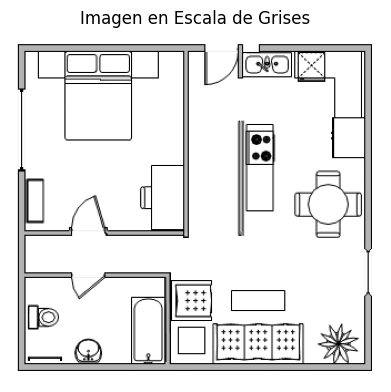

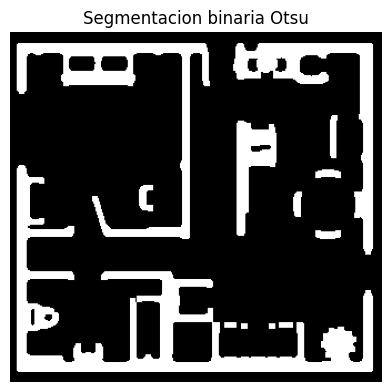

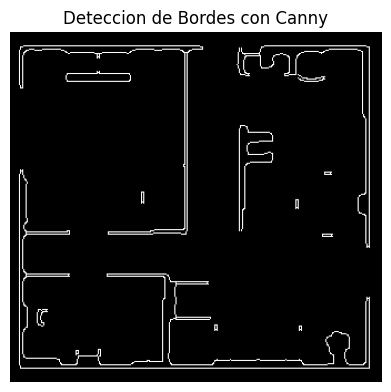

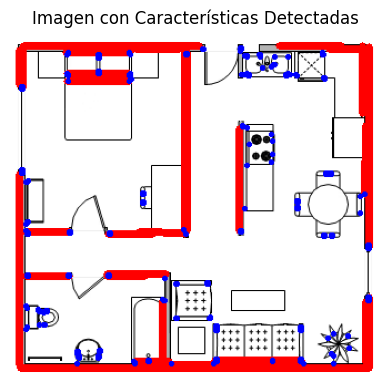

In [ ]:
"""
==================================================================
=  PROYECTO 3                                                    =
=  DESARROLLO DE UNA LIBRERIA EN PYTHON PARA LA DETECCION DE     =
=  LINEAS, ESQUINAS E INTERSECCIONES EN PLANOS ARQUITECTONICOS   =
=                                                                =
==================================================================
  INTEGRANTES:
  - HAN APESS ESPARZA
  - ARMANDO DUARTE ESPARZA
  - IKER EDUARDO FIGUEROA GARCIA
  - JOSE IVAN RODRIGUEZ VALTIERRA

  DESCRIPCION:
  El presente proyecto tiene como objetivo desarrollar una libreria en Python 
  que permita la detección de lineas, esquinas e intersecciones en planos arquitectonicos. 
  Esto se lograra solo usando funciones basicas de procesamiento de imágenes, 
  sin recurrir a librerias especializadas.                                                    
"""
import cv2
import numpy as np
import matplotlib.pyplot as plt

Imagen = cv2.imread("Plano_Arquitectonico.png")
Imagen_gris = cv2.cvtColor(Imagen, cv2.COLOR_BGR2GRAY)

#Detectar bordes usando el operador de Canny
Bordes = cv2.Canny(Imagen_gris, 150, 150)
#Buscar las lineas usando la transformada de Hough solo para calcular el angulo de inclinacion
lineas = cv2.HoughLinesP(Bordes, 1, np.pi / 180, threshold=20, minLineLength=100, maxLineGap=30)

#Si el plano esta chueco usaremos una matriz de transformacion afin para derectar esquinas a 90°
angulos = []
if lineas is not None:
    for l in lineas:
        x1, y1, x2, y2 = l[0]
        # Calculamos el ángulo en grados
        angulo = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        
        # En planos, nos interesan las desviaciones pequeñas del eje 0 o 90
        # Filtramos para quedarnos con lo que no sea perfectamente recto
        if abs(angulo) < 45: # Líneas horizontales
            angulos.append(angulo)
        elif abs(angulo) > 45: # Líneas verticales (ajustamos a 90)
            angulos.append(angulo - 90 if angulo > 0 else angulo + 90)
Angulo_Final = np.median(angulos) if angulos else 0

#Rotar la imagen para corregir la inclinacion
rows, cols = Imagen_gris.shape[:2]
Matriz_Transformacion = cv2.getRotationMatrix2D((cols / 2, rows / 2), Angulo_Final, 1)
Imagen_Rotada = cv2.warpAffine(Imagen, Matriz_Transformacion, (cols, rows))

#Convertimos la imagen a escala de grises
Imagen_gris = cv2.cvtColor(Imagen_Rotada, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1), plt.imshow(Imagen_gris, cmap='gray'), plt.title('Imagen en Escala de Grises'), plt.axis('off')

#Normalizamos la imagen
Imagen_Normalizada = (Imagen_gris - Imagen_gris.min()) / (Imagen_gris.max() - Imagen_gris.min()) * 255
Imagen_Normalizada = Imagen_Normalizada.astype(np.uint8)

#Filtro de Blur Gausssiano
#Este filtro ayuda a reducir el ruido en la imagen, lo que facilita la deteccion de lineas y esquinas.
Imagen_Gaussiana = cv2.GaussianBlur(Imagen_Normalizada, (11, 11), 0)

#Umbralizacion por Otsu
#Este método encuentra automaticamente el umbral optimo para separar el fondo de los objetos en la imagen.
_, Imagen_Binaria = cv2.threshold(Imagen_Gaussiana, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel_limpio = np.ones((5, 5), np.uint8)
Imagen_Limpiada = cv2.morphologyEx(Imagen_Binaria, cv2.MORPH_OPEN, kernel_limpio, iterations=1)

plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 2), plt.imshow(Imagen_Limpiada, cmap='gray'), plt.title('Segmentacion binaria Otsu'), plt.axis('off')

#Aplicamops una erosion para eliminar pequeños ruidos y adelgazar los muros antes de Canny
kernel_erosion = np.ones((7, 7), np.uint8)
Imagen_Limpiada = cv2.erode(Imagen_Limpiada, kernel_erosion, iterations=1)

#Detectar caracterisitcas como son bordes y esquinas
#Detectar bordes usando el operador de Canny
Bordes = cv2.Canny(Imagen_Limpiada, 15, 15, apertureSize=5)
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 3), plt.imshow(Bordes, cmap='gray'), plt.title('Deteccion de Bordes con Canny'), plt.axis('off')

#Detectar esquinas usando el metodo de Harris
#Como el metodo de Harris requiere una imagen en formato float32, convertimos la imagen a este formato.

Harris_gray = np.float32(Imagen_Limpiada)
Esquinas = cv2.cornerHarris(Harris_gray, blockSize=2, ksize=3, k=0.1)
Esquinas = cv2.dilate(Esquinas, None)

#Vamos a "dilatar" para que se vean mas visibles las esquinas.
Imagen_Harris = cv2.dilate(Esquinas, None)

#Para las lineas, utilizamos la transformada de Hough para detectar lineas rectas en la imagen.
Lineas = cv2.HoughLinesP(
    Bordes, 
    rho = 1, 
    theta = np.pi / 180, 
    threshold=54, 
    minLineLength=30, 
    maxLineGap=10
)

#Dibujar las lineas detectadas en la imagen original
Resultado = Imagen_Rotada.copy()
#Vamos a poner las lineas en rojo para que se vean mejor.
if Lineas is not None:
    for linea in Lineas:
        x1, y1, x2, y2 = linea[0]
        cv2.line(Resultado, (x1, y1), (x2, y2), (0, 0, 255), 5)

#Dibujar las esquinas detectadas en la imagen en color azul
Resultado[Esquinas > 0.05 * Esquinas.max()] = [255, 0, 0]
indices_esquinas = np.argwhere(Esquinas > 0.05 * Esquinas.max())
for pt in indices_esquinas:
    cv2.circle(Resultado, (pt[1], pt[0]), 1, (255, 0, 0), -1)
    
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 4), plt.imshow(cv2.cvtColor(Resultado, cv2.COLOR_BGR2RGB)), plt.title('Imagen con Características Detectadas'), plt.axis('off') 